<a href="https://colab.research.google.com/github/gustavo-mrcbg/app-ideas/blob/master/TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

O objetivo deste notebook é classificar uma base de dados complexa utilizando a ideia de Transfer Learning.

#Dataset



## Carregando Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

Mounted at /content/drive


##Carregando Pacotes

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from pathlib import Path
from tensorflow.keras.preprocessing import image_dataset_from_directory

## Parâmetros da base de dados. Note que o tamanho da imagem deve ser igual a imagem esperada pela rede, nesse caso 224x224

In [ ]:
#Path base de dados Drive
nome_base = 'oregon_wildlife'
nome_zip = nome_base + '.zip'
dir_path = Path('/content/drive/MyDrive/INFO7004/')
zip_path = dir_path/nome_zip

# Tamanho imagem
img_rows, img_cols = 224, 224

input_shape = (img_rows, img_cols, 3)

#Batch size

batch_size = 32

##Carregar Base de Dados

https://www.kaggle.com/virtualdvid/oregon-wildlife

In [ ]:
!cp {zip_path} .
!unzip -q {nome_zip}
!rm {nome_zip}

In [ ]:
path_train = '/content/' + nome_base + '/train'
path_test = '/content/' + nome_base + '/test'

In [ ]:
train_dataset = image_dataset_from_directory(
        path_train,
        image_size=(img_rows, img_cols),
        color_mode="rgb",
        batch_size=batch_size,
        shuffle=False) #Somente apresentação da base
test_dataset = image_dataset_from_directory(
        path_test,
        image_size=(img_rows, img_cols),
        color_mode="rgb",
        batch_size=batch_size,
        shuffle=False)

Found 3136 files belonging to 14 classes.
Found 784 files belonging to 14 classes.


A base está balanceada entre as classes com 280 imagens para cada classe.

A base foi dividia em 80% para treino e 20% para teste

https://www.tensorflow.org/api_docs/python/tf/keras/utils/image_dataset_from_directory

main_directory/

...class_a/

......a_image_1.jpg

......a_image_2.jpg

...class_b/

......b_image_1.jpg

......b_image_2.jpg

In [ ]:
classes = train_dataset.class_names
print(classes)

['bald_eagle', 'black_bear', 'bobcat', 'canada_lynx', 'columbian_black-tailed_deer', 'cougar', 'coyote', 'deer', 'gray_wolf', 'raccoon', 'red_fox', 'sea_lions', 'seals', 'virginia_opossum']


In [ ]:
classes_dict = dict(enumerate(classes))
print(classes_dict)

{0: 'bald_eagle', 1: 'black_bear', 2: 'bobcat', 3: 'canada_lynx', 4: 'columbian_black-tailed_deer', 5: 'cougar', 6: 'coyote', 7: 'deer', 8: 'gray_wolf', 9: 'raccoon', 10: 'red_fox', 11: 'sea_lions', 12: 'seals', 13: 'virginia_opossum'}


In [ ]:
np_train = list(train_dataset.unbatch().as_numpy_iterator()) # Passando para uma lista de numpy arrays
np_test = list(test_dataset.unbatch().as_numpy_iterator())
y_train= [y for x, y in np_train] # y para extração de uma imagem de cada classe
y_test= [y for x, y in np_test]

## Visualizando base de Treinamento




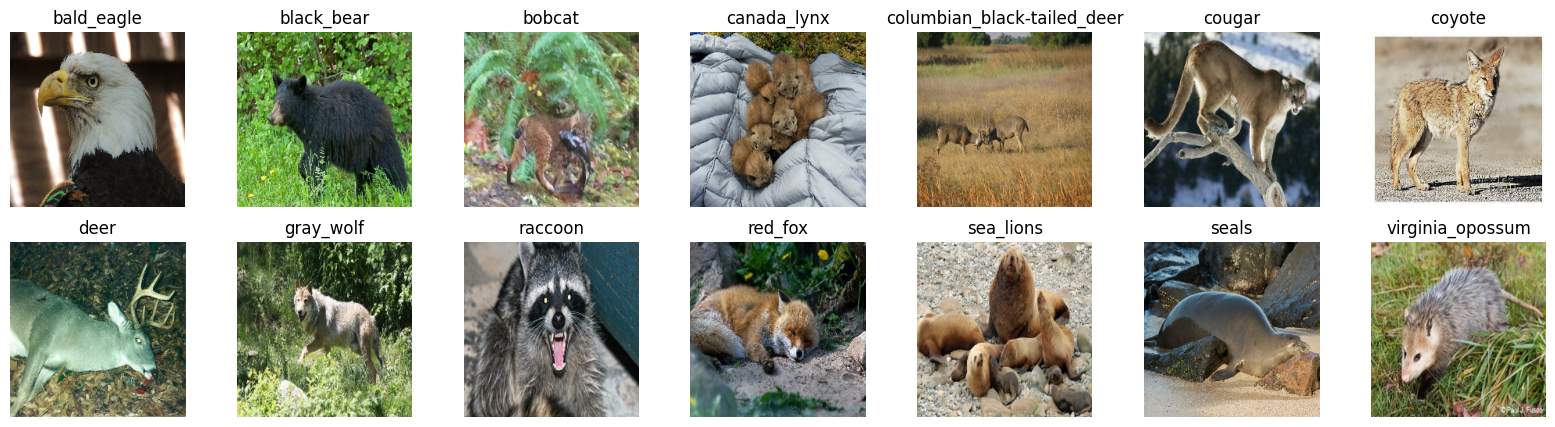

In [ ]:
plt.figure(figsize=(20, 5))
for index in range(14):
  index_y = y_train.index(index)
  image, label = np_train[index_y]
  ax = plt.subplot(2, 7, index + 1)
  plt.imshow(image.astype("uint8"))
  plt.title(classes[label])
  plt.axis("off")

## Visualizando base de Teste

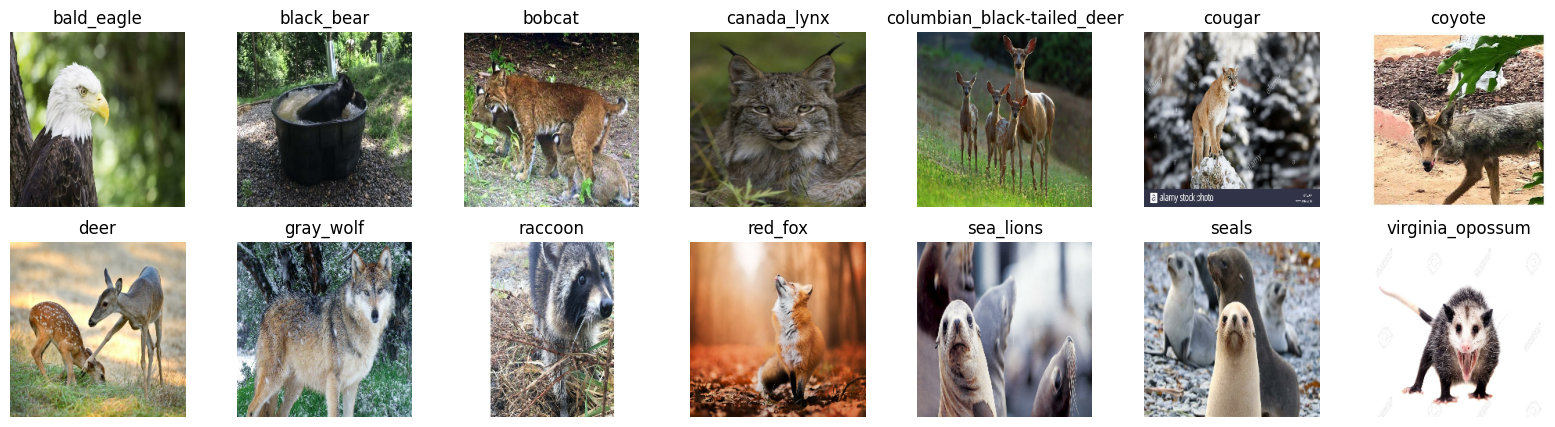

In [ ]:
plt.figure(figsize=(20, 5))
for index in range(14):
  index_y = y_test.index(index)
  image, label = np_test[index_y]
  ax = plt.subplot(2, 7, index + 1)
  plt.imshow(image.astype("uint8"))
  plt.title(classes[label])
  plt.axis("off")

# Extraindo características usando a ResNet50

## Verificando GPU

In [ ]:
!nvidia-smi

Mon Jun 23 18:42:19 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P0             27W /   70W |     104MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Carregando pacotes

In [ ]:
import numpy as np
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.layers import GlobalAveragePooling2D,  Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.layers import RandomFlip, RandomZoom, RandomContrast

from pathlib import Path
import shutil




from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


## Carrega a RenNet50 sem a camada de classificação, mantendo as camadas convolucionais para extração de características

In [ ]:
resnet50_top_false =  ResNet50(include_top=False, input_shape=(224,224,3))
resnet50_top_false.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

##Autotune

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE) #Otimização
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

## Criando o extrator.


1.   Carrega a ResNet sem a camada de classificacao (include_top=false)


In [ ]:
cnn = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
inputs = keras.Input(shape=input_shape)
x = preprocess_input(inputs)
x = cnn(x)
output = GlobalAveragePooling2D()(x)
model = Model(inputs, output)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

## Extraindo características

In [ ]:
X_train = model.predict(train_dataset)
X_test = model.predict(test_dataset)

y_train = np.concatenate([y for x, y in train_dataset], axis=0)
y_test = np.concatenate([y for x, y in test_dataset], axis=0)

print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

98/98 ━━━━━━━━━━━━━━━━━━━━ 25s 167ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 391ms/step
(3136, 2048)
(784, 2048)
(3136,)
(784,)


# Classificando a base usando sklearn

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[54  0  1  0  0  0  0  0  0  1  0  0  0  0]
 [ 0 54  1  0  0  0  0  0  0  1  0  0  0  0]
 [ 1  0 37  9  4  2  0  0  0  2  0  0  0  1]
 [ 0  0  8 42  0  3  1  0  1  1  0  0  0  0]
 [ 0  0  1  0 42  0  4  9  0  0  0  0  0  0]
 [ 0  0  2  3  0 49  0  1  0  1  0  0  0  0]
 [ 0  0  0  0  0  0 49  1  6  0  0  0  0  0]
 [ 0  0  0  2 17  1  1 35  0  0  0  0  0  0]
 [ 0  1  0  2  0  2 11  0 39  0  0  0  0  1]
 [ 0  1  2  0  0  0  0  0  0 51  0  0  0  2]
 [ 0  0  0  0  0  0  1  0  0  0 55  0  0  0]
 [ 0  0  0  1  1  0  0  0  0  0  0 41 12  1]
 [ 0  0  0  0  0  0  0  0  0  0  0 20 36  0]
 [ 0  0  0  0  0  0  0  0  0  6  0  0  1 49]]
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        56
           1       0.96      0.96      0.96        56
           2       0.71      0.66      0.69        56
           3       0.71      0.75      0.73        56
           4       0.66      0.75      0.70        56
           5       0.86      0.88      0.87 

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[56  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 56  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 1  1 42  4  5  0  2  1  0  0  0  0  0  0]
 [ 0  0 10 44  0  0  0  0  1  1  0  0  0  0]
 [ 0  0  2  0 41  0  1 12  0  0  0  0  0  0]
 [ 0  0  4  2  1 48  0  0  0  0  0  0  1  0]
 [ 0  0  1  0  2  0 47  0  6  0  0  0  0  0]
 [ 0  0  0  0 14  1  1 38  0  0  0  1  1  0]
 [ 0  2  0  1  0  1  8  0 43  0  0  0  0  1]
 [ 0  1  1  0  0  0  0  0  0 52  0  0  0  2]
 [ 0  0  0  0  2  0  0  0  0  0 54  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 48  8  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 15 41  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  1  1 54]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        56
           1       0.93      1.00      0.97        56
           2       0.70      0.75      0.72        56
           3       0.86      0.79      0.82        56
           4       0.63      0.73      0.68        56
           5       0.96      0.86      0.91 

# Treinando uma nova camanda de saida para a ResNet

 **tf.data.AUTOTUNE**: É uma constante especial do TensorFlow que permite que o tempo de execução do TensorFlow ajuste dinamicamente o número ideal de elementos a serem pré-buscados ou o número de threads a serem usadas para paralelismo

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE) #Otimização
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
import tensorflow as tf
print(tf.__version__)  # Should be 2.7+ for the latest imports

2.18.0


In [ ]:

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2)
])

In [ ]:
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metrics = ['accuracy']

num_classes = 14
n_epochs = 100
batch_size = 32

# seed
seed=42

resnet50 = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
resnet50.trainable = False #Congela todas as camadas de convolução
inputs = keras.Input(shape=input_shape)
x = data_augmentation(inputs)
x = preprocess_input(x)
x = resnet50(x, training=False) #Camadas de Batch Normalization em inference mode
x = GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.4)(x) # Camada de Dropout
predictions = Dense(num_classes)(x) #Camada Densa sem ativação, pois a loss foi definida como from_logits=True
model = Model(inputs, predictions)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 14)        │     28,686 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,616,398 (90.09 MB)

 Trainable params: 28,686 (112.05 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
opt_dense = keras.optimizers.Adam()
model.compile(metrics=metrics, loss=loss, optimizer=opt_dense)
callbacks_dense = [EarlyStopping(patience=50)]

history_dense =model.fit(train_dataset, epochs=n_epochs, verbose=1, validation_data=test_dataset, callbacks=callbacks_dense)

Epoch 1/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 39s 268ms/step - accuracy: 0.1715 - loss: 7.0669 - val_accuracy: 0.0727 - val_loss: 6.1414
Epoch 2/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 15s 153ms/step - accuracy: 0.0181 - loss: 6.7888 - val_accuracy: 0.1798 - val_loss: 4.5423
Epoch 3/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 23s 178ms/step - accuracy: 0.2419 - loss: 3.8021 - val_accuracy: 0.3393 - val_loss: 3.9211
Epoch 4/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 15s 157ms/step - accuracy: 0.3673 - loss: 3.2785 - val_accuracy: 0.4298 - val_loss: 3.5033
Epoch 5/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 15s 155ms/step - accuracy: 0.4095 - loss: 3.0290 - val_accuracy: 0.5383 - val_loss: 2.8259
Epoch 6/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step - accuracy: 0.4587 - loss: 2.7427 - val_accuracy: 0.5918 - val_loss: 2.4076
Epoch 7/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 17s 176ms/step - accuracy: 0.4982 - loss: 2.5619 - val_accuracy: 0.6199 - val_loss: 2.2837
Epoch 8/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 18s 153ms/step - accuracy: 0.5272 - loss: 2.4897 - 

In [ ]:
# Get raw predictions (logits)
y_pred_logits = model.predict(test_dataset)

# Convert logits to class probabilities (if using softmax activation)
y_pred_probs = tf.nn.softmax(y_pred_logits).numpy()
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_test = np.concatenate([y for x, y in test_dataset], axis=0)

accuracy = np.mean(y_pred_classes == y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 184ms/step
Test Accuracy: 82.40%


# Fine Tuning

In [ ]:
resnet50.trainable = True
for layer in resnet50.layers[:140]:  # Freeze the first 140 layers, train the rest
    layer.trainable = False



In [ ]:
fine_tune = keras.optimizers.Adam()
model.compile(metrics=metrics, loss=loss, optimizer=fine_tune)
callbacks_ft = [EarlyStopping(patience=50)]

history_dense =model.fit(train_dataset, epochs=n_epochs, verbose=1, validation_data=test_dataset, callbacks=callbacks_ft)

Epoch 1/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 258ms/step - accuracy: 0.4378 - loss: 5.6698 - val_accuracy: 0.0714 - val_loss: 782.1469
Epoch 2/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 23s 237ms/step - accuracy: 0.1128 - loss: 4.2027 - val_accuracy: 0.3023 - val_loss: 10.1074
Epoch 3/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 41s 234ms/step - accuracy: 0.3266 - loss: 2.7891 - val_accuracy: 0.3342 - val_loss: 4.8466
Epoch 4/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 216ms/step - accuracy: 0.4086 - loss: 2.1755 - val_accuracy: 0.2972 - val_loss: 4.7290
Epoch 5/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 214ms/step - accuracy: 0.5223 - loss: 1.8174 - val_accuracy: 0.3023 - val_loss: 3.9615
Epoch 6/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 41s 211ms/step - accuracy: 0.5947 - loss: 1.6413 - val_accuracy: 0.4375 - val_loss: 2.2356
Epoch 7/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 41s 216ms/step - accuracy: 0.6491 - loss: 1.3068 - val_accuracy: 0.3406 - val_loss: 8.6042
Epoch 8/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 23s 237ms/step - accuracy: 0.7309 - loss: 1.1672

In [ ]:
# Get raw predictions (logits)
y_pred_logits = model.predict(test_dataset)

# Convert logits to class probabilities (if using softmax activation)
y_pred_probs = tf.nn.softmax(y_pred_logits).numpy()
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_test = np.concatenate([y for x, y in test_dataset], axis=0)

accuracy = np.mean(y_pred_classes == y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 182ms/step
Test Accuracy: 51.02%
